SKIP: interactive analysis notebook (no savefig). Re-export manually as needed.

# UnitTest8B — Spot Tolerance Ablation Analysis

Llama-3.1-8B-Instruct, 2× g6.xlarge, 1 pipeline (2 stages, 16+16 layers)

**Events**: t=3min interrupt node1, t=6min restore node1 + interrupt node2, t=9min restore node2

| System | Mode | Event Handling |
|--------|------|----------------|
| OnlyOnDemand | default | none (baseline) |
| ShuntServe | migration | switch_nodes (hot) |
| ConcurrentInit | re-routing | switch_nodes (hot) |
| RequestMigration | migration | stop_nodes + create_pipeline (cold) |
| NoHandle | re-routing | stop_nodes + create_pipeline (cold) |

In [1]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load JSON results
RESULT_DIR = ".."
json_files = {
    "OnlyOnDemand": "offline_only_ondemand.json",
    "ShuntServe": "offline_shuntserve.json",
    "ConcurrentInit": "offline_concurrent_initialization.json",
    "RequestMigration": "offline_request_migration.json",
    "NoHandle": "offline_no_handle.json",
}

results = {}
for name, fname in json_files.items():
    with open(f"{RESULT_DIR}/{fname}") as f:
        results[name] = json.load(f)

SYSTEMS = ["OnlyOnDemand", "ShuntServe", "ConcurrentInit", "RequestMigration", "NoHandle"]
COLORS = {
    "OnlyOnDemand": "#9C27B0",
    "ShuntServe": "#2196F3",
    "ConcurrentInit": "#4CAF50",
    "RequestMigration": "#FF9800",
    "NoHandle": "#F44336",
}

df_summary = pd.DataFrame([
    {"system": name, **{k: v for k, v in data.items() if not isinstance(v, (dict, list))}}
    for name, data in results.items()
])
df_summary = df_summary.set_index("system")
df_summary[["completed", "request_throughput", "output_throughput", "total_token_throughput",
            "mean_ttft_ms", "median_ttft_ms", "mean_tpot_ms", "mean_e2el_ms", "benchmark_duration"]]

,completed,request_throughput,output_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,mean_tpot_ms,mean_e2el_ms,benchmark_duration
system,,,,,,,,,
OnlyOnDemand,1204,1.671140,436.023103,1690.159293,11537.033762,8945.217490,274.748837,81917.612096,720.466411
ShuntServe,1050,1.457069,368.086186,1419.702920,8854.251560,7053.238392,315.924386,85823.486291,720.624707
ConcurrentInitialization,1003,1.391770,346.590858,1340.386472,36430.343638,21397.624969,275.584923,99504.720097,720.665286
RequestMigration,729,1.011837,253.028761,958.910994,8173.175274,7821.871996,424.218603,118202.363120,720.471456
NoHandle,631,0.875807,220.664620,830.148895,97495.440534,83105.845928,263.988306,159223.861112,720.477982


## Throughput Comparison

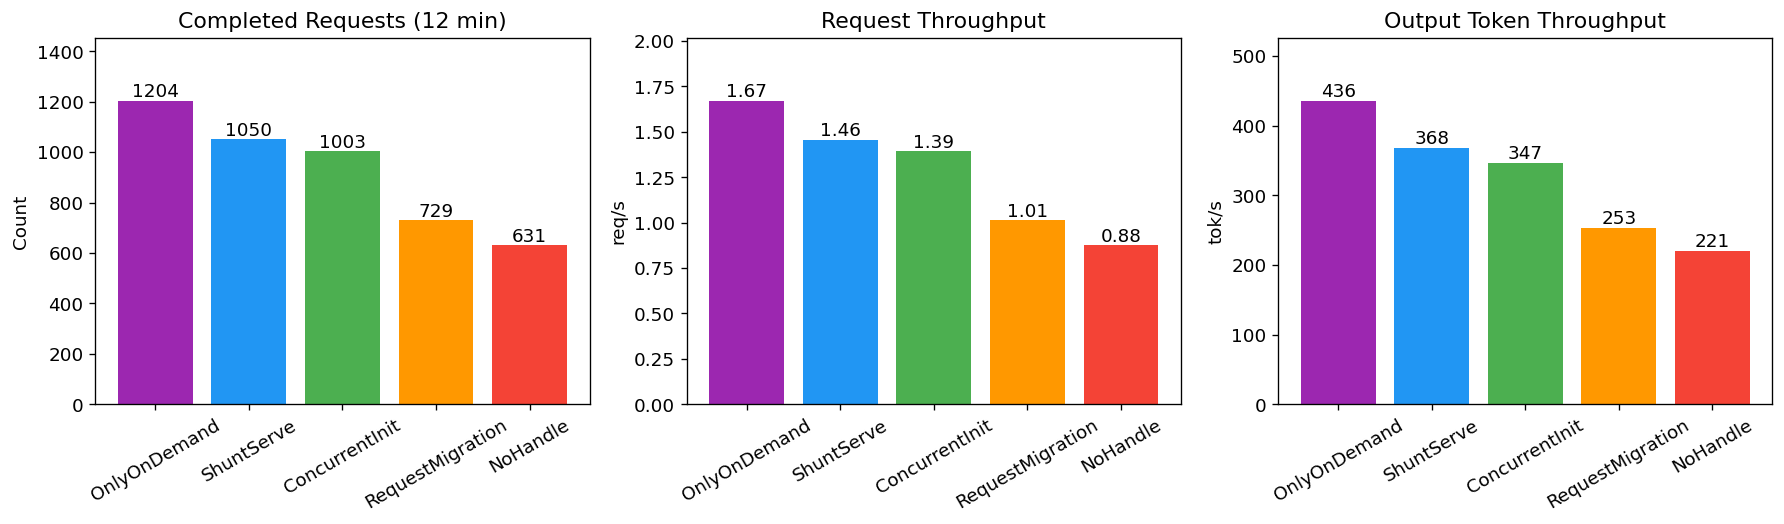

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Completed requests
vals = [results[s]["completed"] for s in SYSTEMS]
bars = axes[0].bar(SYSTEMS, vals, color=[COLORS[s] for s in SYSTEMS])
axes[0].set_title("Completed Requests (12 min)")
axes[0].set_ylabel("Count")
axes[0].bar_label(bars, fmt="%d")

# Request throughput
vals = [results[s]["request_throughput"] for s in SYSTEMS]
bars = axes[1].bar(SYSTEMS, vals, color=[COLORS[s] for s in SYSTEMS])
axes[1].set_title("Request Throughput")
axes[1].set_ylabel("req/s")
axes[1].bar_label(bars, fmt="%.2f")

# Output token throughput
vals = [results[s]["output_throughput"] for s in SYSTEMS]
bars = axes[2].bar(SYSTEMS, vals, color=[COLORS[s] for s in SYSTEMS])
axes[2].set_title("Output Token Throughput")
axes[2].set_ylabel("tok/s")
axes[2].bar_label(bars, fmt="%.0f")

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

## Latency Comparison (TTFT / TPOT / E2E)

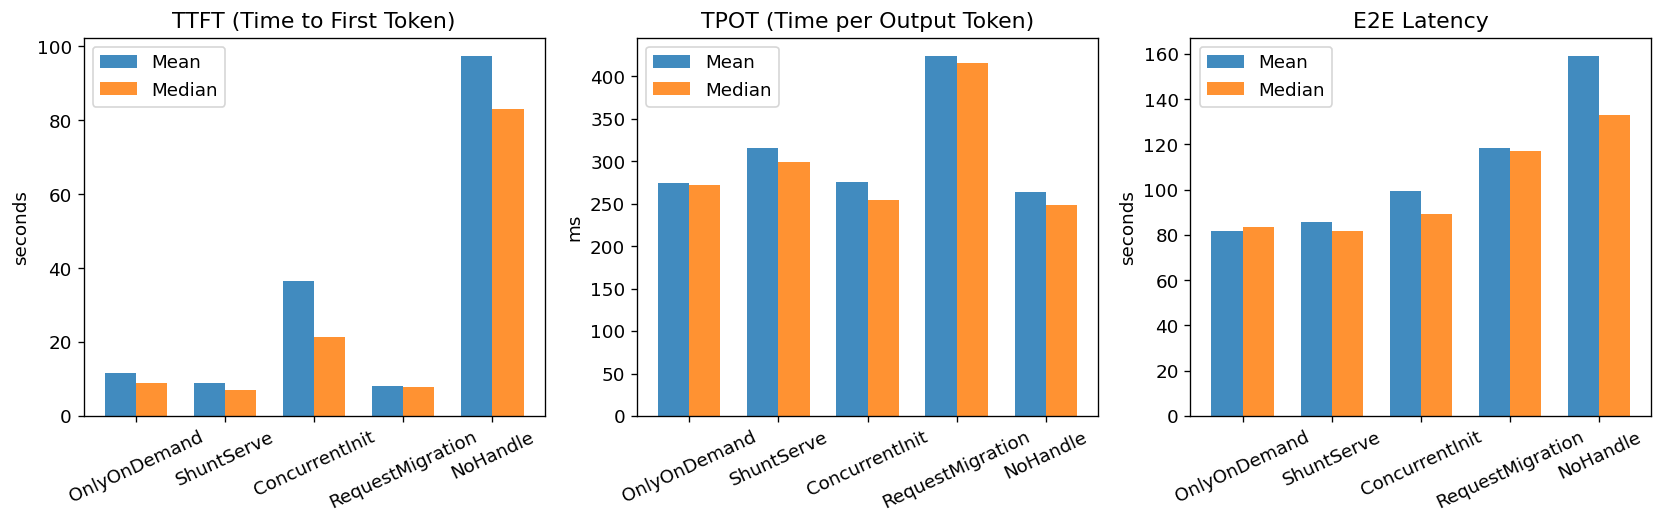

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# TTFT
metrics = ["mean_ttft_ms", "median_ttft_ms"]
labels = ["Mean", "Median"]
x = np.arange(len(SYSTEMS))
w = 0.35
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [results[s][m] / 1000 for s in SYSTEMS]  # ms -> s
    bars = axes[0].bar(x + i * w - w/2, vals, w, label=label, alpha=0.85)
axes[0].set_title("TTFT (Time to First Token)")
axes[0].set_ylabel("seconds")
axes[0].set_xticks(x)
axes[0].set_xticklabels(SYSTEMS, rotation=25)
axes[0].legend()

# TPOT
metrics = ["mean_tpot_ms", "median_tpot_ms"]
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [results[s][m] for s in SYSTEMS]  # keep ms
    bars = axes[1].bar(x + i * w - w/2, vals, w, label=label, alpha=0.85)
axes[1].set_title("TPOT (Time per Output Token)")
axes[1].set_ylabel("ms")
axes[1].set_xticks(x)
axes[1].set_xticklabels(SYSTEMS, rotation=25)
axes[1].legend()

# E2E
metrics = ["mean_e2el_ms", "median_e2el_ms"]
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [results[s][m] / 1000 for s in SYSTEMS]
    bars = axes[2].bar(x + i * w - w/2, vals, w, label=label, alpha=0.85)
axes[2].set_title("E2E Latency")
axes[2].set_ylabel("seconds")
axes[2].set_xticks(x)
axes[2].set_xticklabels(SYSTEMS, rotation=25)
axes[2].legend()

plt.tight_layout()
plt.show()

## Load CSV Traces

In [4]:
TRACE_DIR = "../Trace"
csv_files = {
    "OnlyOnDemand": sorted(glob.glob(f"{TRACE_DIR}/spottolerance_offline_only_ondemand_*.csv"))[-1],
    "ShuntServe": sorted(glob.glob(f"{TRACE_DIR}/spottolerance_offline_shuntserve_*.csv"))[-1],
    "ConcurrentInit": sorted(glob.glob(f"{TRACE_DIR}/spottolerance_offline_concurrent_initialization_*.csv"))[-1],
    "RequestMigration": sorted(glob.glob(f"{TRACE_DIR}/spottolerance_offline_request_migration_*.csv"))[-1],
    "NoHandle": sorted(glob.glob(f"{TRACE_DIR}/spottolerance_offline_no_handle_*.csv"))[-1],
}

traces = {}
for name, path in csv_files.items():
    df = pd.read_csv(path)
    df["system"] = name
    # Normalize time to start from 0 (minutes)
    t0 = df["ArrivalTime"].min()
    df["arrival_min"] = (df["ArrivalTime"] - t0) / 60
    df["completion_min"] = (df["CompletionTime"] - t0) / 60
    traces[name] = df
    print(f"{name}: {len(df)} requests, {path.split('/')[-1]}")

df_all = pd.concat(traces.values(), ignore_index=True)

OnlyOnDemand: 1204 requests, spottolerance_offline_only_ondemand_unittest8b_20260320_1115.csv
ShuntServe: 1050 requests, spottolerance_offline_shuntserve_unittest8b_20260320_0918.csv
ConcurrentInit: 1003 requests, spottolerance_offline_concurrent_initialization_unittest8b_20260320_1026.csv
RequestMigration: 729 requests, spottolerance_offline_request_migration_unittest8b_20260320_1046.csv
NoHandle: 631 requests, spottolerance_offline_no_handle_unittest8b_20260320_1100.csv


## Timeline — Throughput over Time (30s sliding window)

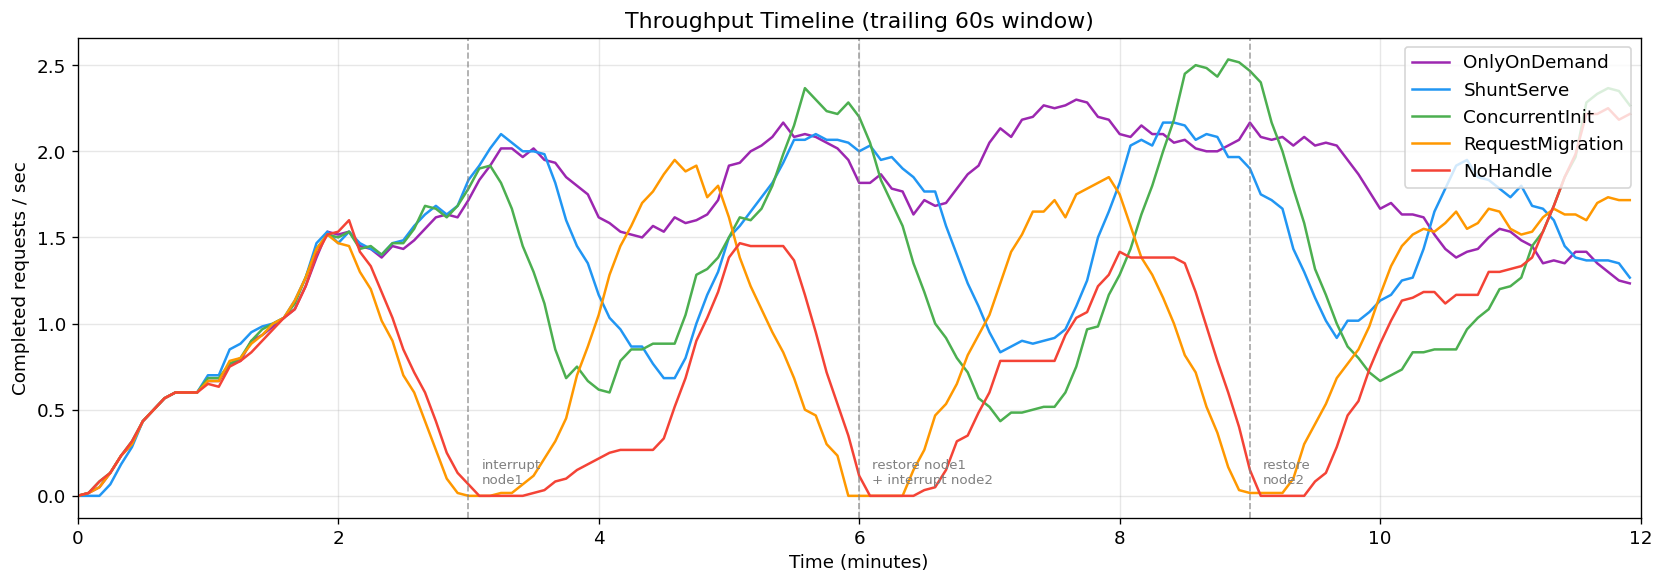

In [5]:
EVENT_TIMES_MIN = [3, 6, 9]  # interrupt, restore+interrupt, restore
EVENT_LABELS = ["interrupt\nnode1", "restore node1\n+ interrupt node2", "restore\nnode2"]
WINDOW_SEC = 60

fig, ax = plt.subplots(figsize=(14, 5))

for name in SYSTEMS:
    df = traces[name]
    t0 = df["ArrivalTime"].min()
    completions = (df["CompletionTime"] - t0).sort_values().values  # seconds from start

    # Trailing (causal) window: count completions in [t - window, t]
    time_points = np.arange(0, 720, 5)  # every 5 seconds
    throughputs = []
    for t in time_points:
        count = np.sum((completions >= t - WINDOW_SEC) & (completions < t))
        throughputs.append(count / WINDOW_SEC)

    ax.plot(time_points / 60, throughputs, label=name, color=COLORS[name], linewidth=1.5)

# Event markers
for t, label in zip(EVENT_TIMES_MIN, EVENT_LABELS):
    ax.axvline(x=t, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(t + 0.1, ax.get_ylim()[1] * 0.02, label, fontsize=8, color='gray', va='bottom')

ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Completed requests / sec")
ax.set_title(f"Throughput Timeline (trailing {WINDOW_SEC}s window)")
ax.legend(loc="upper right")
ax.set_xlim(0, 12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Timeline — E2E Latency over Time (by arrival time, trailing 30s window median)

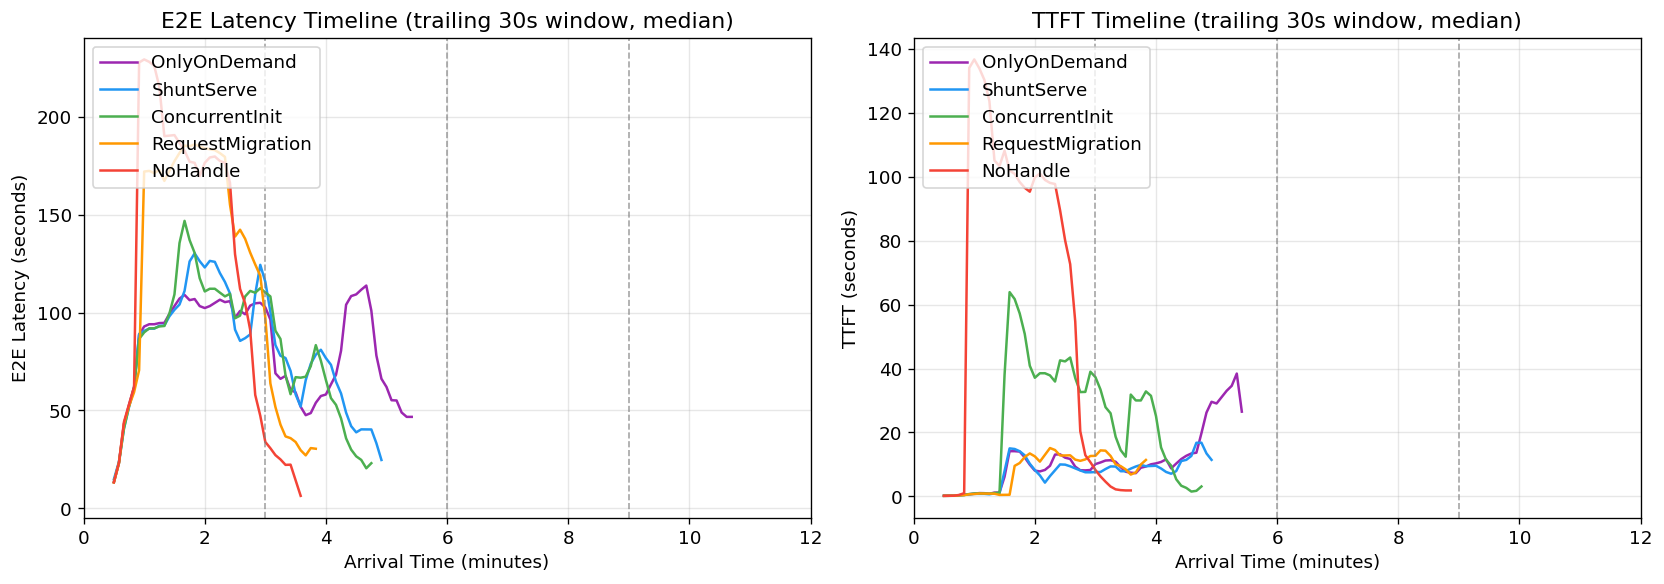

In [6]:
LATENCY_WINDOW_SEC = 30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, title in [
    (axes[0], "Latency", "E2E Latency (seconds)", "E2E Latency Timeline"),
    (axes[1], "TTFT", "TTFT (seconds)", "TTFT Timeline"),
]:
    for name in SYSTEMS:
        df = traces[name]
        t0 = df["ArrivalTime"].min()
        arrivals = (df["ArrivalTime"] - t0).values  # seconds from start
        latencies = df[metric].values

        # Sort by arrival time
        sort_idx = np.argsort(arrivals)
        arrivals = arrivals[sort_idx]
        latencies = latencies[sort_idx]

        # Trailing window median: for each time point, median latency of requests arriving in [t - window, t]
        time_points = np.arange(LATENCY_WINDOW_SEC, 720, 5)
        medians = []
        for t in time_points:
            mask = (arrivals >= t - LATENCY_WINDOW_SEC) & (arrivals < t)
            if mask.sum() > 0:
                medians.append(np.median(latencies[mask]))
            else:
                medians.append(np.nan)

        ax.plot(time_points / 60, medians, label=name, color=COLORS[name], linewidth=1.5)

    for t, label in zip(EVENT_TIMES_MIN, EVENT_LABELS):
        ax.axvline(x=t, color='gray', linestyle='--', alpha=0.7, linewidth=1)

    ax.set_xlabel("Arrival Time (minutes)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} (trailing {LATENCY_WINDOW_SEC}s window, median)")
    ax.legend(loc="upper left")
    ax.set_xlim(0, 12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## CDF — E2E Latency & TTFT

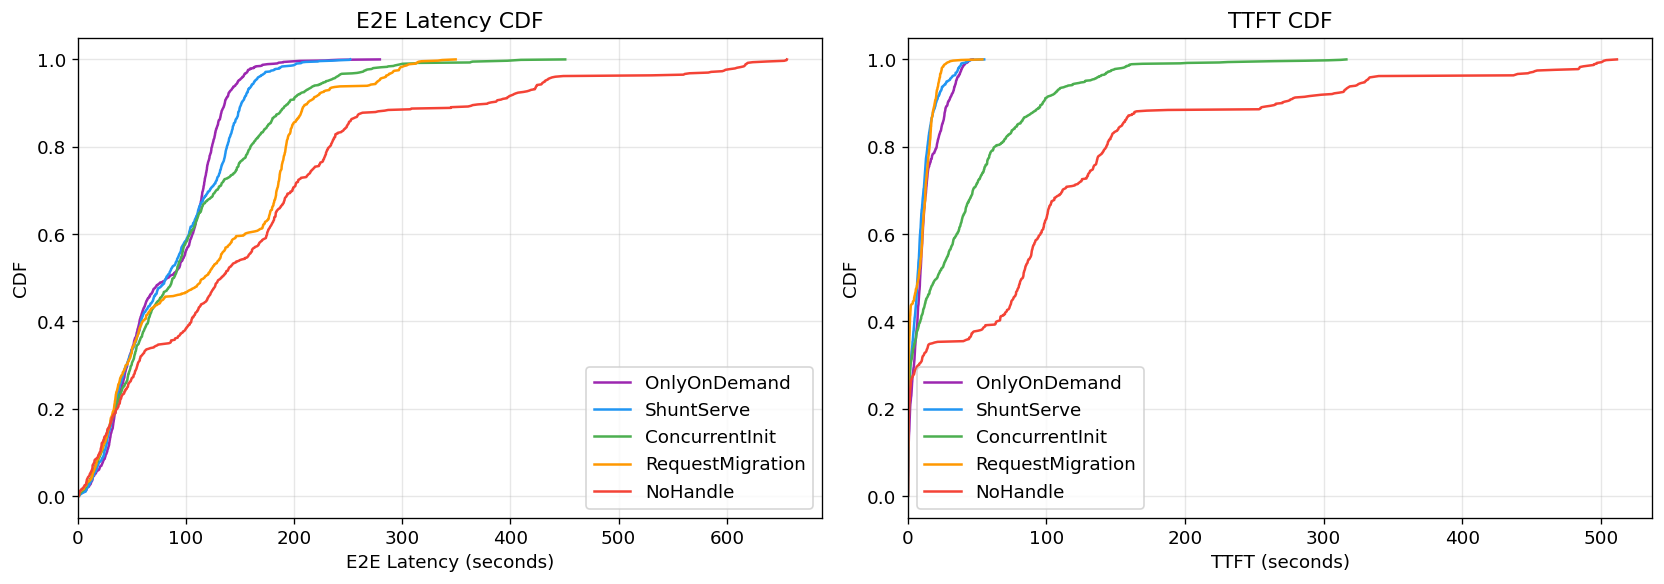

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# E2E Latency CDF
for name in SYSTEMS:
    df = traces[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=name, color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title("E2E Latency CDF")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

# TTFT CDF
for name in SYSTEMS:
    df = traces[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=name, color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title("TTFT CDF")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

## SendCount Distribution (Migration Analysis)

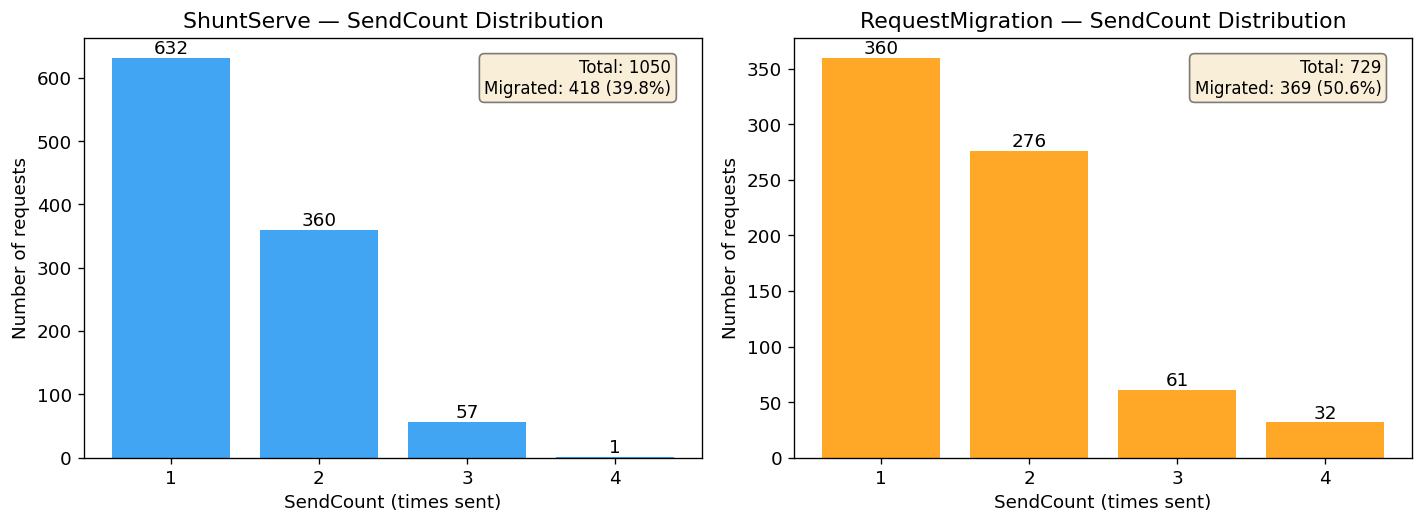

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, name in zip(axes, ["ShuntServe", "RequestMigration"]):
    df = traces[name]
    counts = df["SendCount"].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=COLORS[name], alpha=0.85)
    ax.bar_label(bars)
    ax.set_xlabel("SendCount (times sent)")
    ax.set_ylabel("Number of requests")
    ax.set_title(f"{name} — SendCount Distribution")

    total = len(df)
    migrated = (df["SendCount"] > 1).sum()
    ax.text(0.95, 0.95, f"Total: {total}\nMigrated: {migrated} ({migrated/total*100:.1f}%)",
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Same-Request CDF — Filtered by NoHandle RequestIDs

NoHandle가 가장 적은 요청을 처리했으므로 (631개), 동일한 RequestID set으로 모든 시스템을 필터링하여 공정 비교.

In [9]:
# Find the system with fewest completed requests as baseline
baseline_system = min(SYSTEMS, key=lambda s: len(traces[s]))
baseline_ids = set(traces[baseline_system]["RequestID"].values)
print(f"Baseline: {baseline_system} ({len(baseline_ids)} requests)")

# Check how many of these IDs each system has
for name in SYSTEMS:
    common = set(traces[name]["RequestID"].values) & baseline_ids
    print(f"  {name}: {len(common)} / {len(baseline_ids)} common IDs ({len(common)/len(baseline_ids)*100:.1f}%)")

# Filter all systems to common IDs (intersection across ALL systems)
common_ids = baseline_ids.copy()
for name in SYSTEMS:
    common_ids &= set(traces[name]["RequestID"].values)
print(f"\nCommon across ALL systems: {len(common_ids)} requests")

filtered = {}
for name in SYSTEMS:
    df = traces[name]
    filtered[name] = df[df["RequestID"].isin(common_ids)].copy()
    print(f"  {name}: {len(filtered[name])} requests after filtering")

Baseline: NoHandle (631 requests)
  OnlyOnDemand: 631 / 631 common IDs (100.0%)
  ShuntServe: 618 / 631 common IDs (97.9%)
  ConcurrentInit: 631 / 631 common IDs (100.0%)
  RequestMigration: 602 / 631 common IDs (95.4%)
  NoHandle: 631 / 631 common IDs (100.0%)

Common across ALL systems: 600 requests
  OnlyOnDemand: 600 requests after filtering
  ShuntServe: 600 requests after filtering
  ConcurrentInit: 600 requests after filtering
  RequestMigration: 600 requests after filtering
  NoHandle: 600 requests after filtering


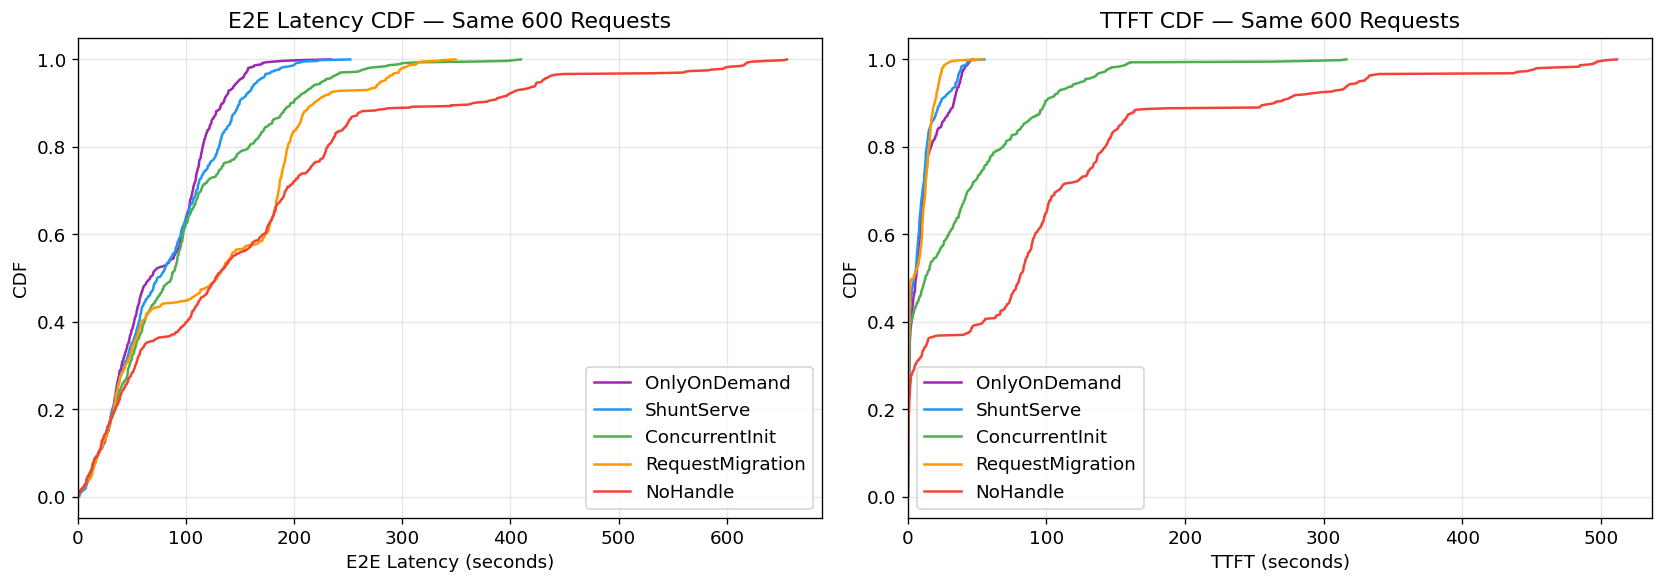

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# E2E Latency CDF (same requests)
for name in SYSTEMS:
    df = filtered[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=name, color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title(f"E2E Latency CDF — Same {len(common_ids)} Requests")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

# TTFT CDF (same requests)
for name in SYSTEMS:
    df = filtered[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=name, color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title(f"TTFT CDF — Same {len(common_ids)} Requests")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

In [11]:
# Same-request summary statistics
print(f"Same-request comparison ({len(common_ids)} common RequestIDs)")
print(f"{'System':20s} {'Mean E2E':>10s} {'P50 E2E':>10s} {'P99 E2E':>10s} {'Mean TTFT':>10s} {'P99 TTFT':>10s}")
for name in SYSTEMS:
    df = filtered[name]
    print(f"{name:20s} "
          f"{df['Latency'].mean():10.1f} "
          f"{df['Latency'].median():10.1f} "
          f"{df['Latency'].quantile(0.99):10.1f} "
          f"{df['TTFT'].mean():10.1f} "
          f"{df['TTFT'].quantile(0.99):10.1f}")

Same-request comparison (600 common RequestIDs)
System                 Mean E2E    P50 E2E    P99 E2E  Mean TTFT   P99 TTFT
OnlyOnDemand               75.3       67.0      170.5       10.1       43.2
ShuntServe                 81.2       74.0      201.2        8.5       42.4
ConcurrentInit             96.0       86.6      298.5       34.4      157.9
RequestMigration          122.1      128.8      312.8        7.7       27.9
NoHandle                  154.5      127.5      617.0       94.1      494.8


## Ablation Summary — 2×2 Matrix (Hot/Cold × Migration/Re-routing)

In [12]:
# 2x2 ablation matrix
ablation = {
    ("Hot (switch_nodes)", "Migration"): "ShuntServe",
    ("Hot (switch_nodes)", "Re-routing"): "ConcurrentInit",
    ("Cold (stop+create)", "Migration"): "RequestMigration",
    ("Cold (stop+create)", "Re-routing"): "NoHandle",
}

rows = ["Hot (switch_nodes)", "Cold (stop+create)"]
cols = ["Migration", "Re-routing"]

print("=" * 80)
print(f"{'':25s} | {'Migration':25s} | {'Re-routing':25s}")
print("-" * 80)
for row in rows:
    cells = []
    for col in cols:
        s = ablation[(row, col)]
        cell = f"{s}\n  completed={results[s]['completed']}\n  req/s={results[s]['request_throughput']:.2f}\n  E2E={results[s]['mean_e2el_ms']/1000:.1f}s\n  TTFT={results[s]['mean_ttft_ms']/1000:.1f}s"
        cells.append(cell)
    lines_left = cells[0].split("\n")
    lines_right = cells[1].split("\n")
    max_lines = max(len(lines_left), len(lines_right))
    for i in range(max_lines):
        left = lines_left[i] if i < len(lines_left) else ""
        right = lines_right[i] if i < len(lines_right) else ""
        prefix = row if i == 0 else ""
        print(f"{prefix:25s} | {left:25s} | {right:25s}")
    print("-" * 80)

# Normalized comparison table (baseline = OnlyOnDemand)
print("\n\nNormalized to OnlyOnDemand (baseline = 1.00):")
print(f"{'System':20s} {'Completed':>10s} {'Req/s':>10s} {'E2E':>10s} {'TTFT':>10s}")
base = results["OnlyOnDemand"]
for name in SYSTEMS:
    r = results[name]
    print(f"{name:20s} "
          f"{r['completed']/base['completed']:10.2f} "
          f"{r['request_throughput']/base['request_throughput']:10.2f} "
          f"{r['mean_e2el_ms']/base['mean_e2el_ms']:10.2f} "
          f"{r['mean_ttft_ms']/base['mean_ttft_ms']:10.2f}")

                          | Migration                 | Re-routing               
--------------------------------------------------------------------------------
Hot (switch_nodes)        | ShuntServe                | ConcurrentInit           
                          |   completed=1050          |   completed=1003         
                          |   req/s=1.46              |   req/s=1.39             
                          |   E2E=85.8s               |   E2E=99.5s              
                          |   TTFT=8.9s               |   TTFT=36.4s             
--------------------------------------------------------------------------------
Cold (stop+create)        | RequestMigration          | NoHandle                 
                          |   completed=729           |   completed=631          
                          |   req/s=1.01              |   req/s=0.88             
                          |   E2E=118.2s              |   E2E=159.2s             
                  